## Generate a white Gaussian noise signal. Estimate its mean, variance

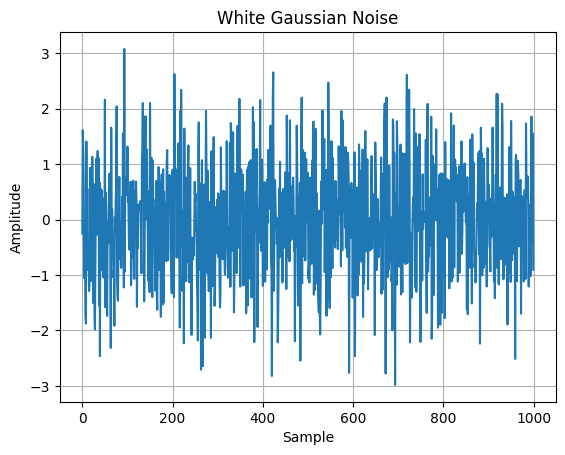

Estimated Mean: -0.0104
Estimated Variance: 0.9850


In [3]:
#1. White Gaussian Noise (WGN)}
#A zero-mean, normally distributed random signal with flat power spectral density.
import numpy as np
import matplotlib.pyplot as plt

N = 1000
white_noise = np.random.normal(loc=0.0, scale=1.0, size=N)

# Statistical properties
mean = np.mean(white_noise)
variance = np.var(white_noise)

plt.plot(white_noise)
plt.title("White Gaussian Noise")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

print(f"Estimated Mean: {mean:.4f}")
print(f"Estimated Variance: {variance:.4f}")

## Check for ergodicity using a running mean.

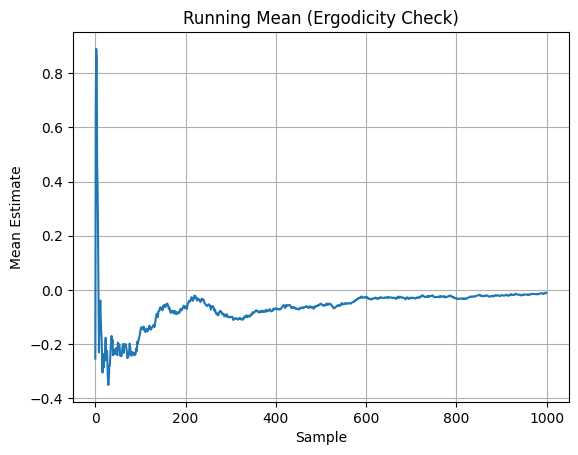

In [5]:
running_mean = np.cumsum(white_noise) / np.arange(1, N + 1)

plt.figure()
plt.plot(running_mean)
plt.title("Running Mean (Ergodicity Check)")
plt.xlabel("Sample")
plt.ylabel("Mean Estimate")
plt.grid(True)

## Estimate the PSD using the periodogram method and interpret the result.

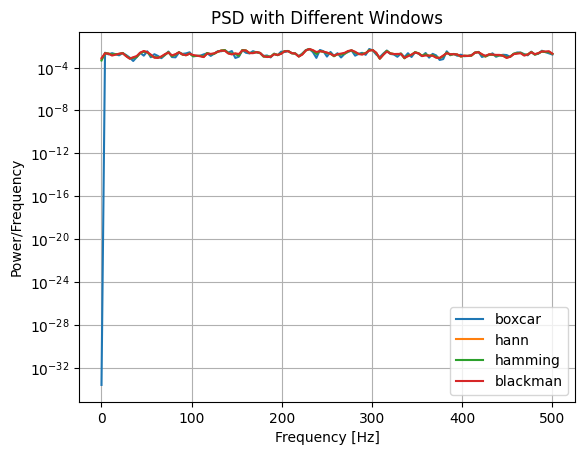

In [10]:
# psd - ile energii sygnał ma na każdej częstotliwości
from scipy.signal import get_window
from scipy.signal import welch

windows = ['boxcar', 'hann', 'hamming', 'blackman']

fs = 1000

plt.figure()
for win in windows:
    # welch dzieli sygnał na segmenty liczy FFT dla każdego uśrednia wynik
    f, Pxx = welch(white_noise, fs=fs, window=win, nperseg=256)
    plt.semilogy(f, Pxx, label=win)

plt.title("PSD with Different Windows")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power/Frequency")
plt.legend()
plt.grid(True)
plt.show()